# Notebook 2 – Communication: Symbols, Safe margin, and Optimization 

__LyQoD general simulator – notes, part 2 of 3__ 

This notebook covers the M-PSK communication model and the per-slot optimization 
that turns a channel + symbol draw into a transmit vector $\tilde{\mathbf{x}}$: 
the safe-margin constraints, the LP relaxation, greedy rounding, and the resulting SEP/BER. 
As in Notebook 1, each section is a standalone reimplementation.

## 1-0. Setup

In [1]:
import sys, pathlib 
REPO_ROOT = pathlib.Path.cwd().parent 
if str(REPO_ROOT) not in sys.path: 
    sys.path.insert(0, str(REPO_ROOT)) 


import numpy as np 
import matplotlib.pyplot as plt 
from scipy.optimize import linprog 
from scipy.special import erfc 

%matplotlib inline 
plt.rcParams["figure.dpi"] = 100 
RNG = np.random.default_rng(0) 



## 1-1. Transmitted and received symbols (communication only) 

User $u$ receives, in slot $t$: 
$$ 
\begin{equation} 
    y_u(t) = \mathbf{h}_{u}(t)^{\mathrm{H}} \mathbf{x}(t) + n_{C, u}(t), \quad n_{C, u}(t) \sim \mathcal{CN}(0, \sigma^{2}_{C, u}), 
\end{equation}
$$
with $\mathbf{h}_u(t)$ the block-Rayleigh channel and $\mathbf{s}_u(t)$ the desired $M$-psk symbol. 
Two things are worth seeing separately before any optimization enters the picture: 

- __Tx symbols__: The $K$ users' desired $M$-PSK symbols $s_u(t) = e^{j 2 \pi k / M}$, unit-modulus points on the constellation circle. 
- __Rx symbols__: for one fixed transmit vector $\tilde{\mathbf{x}}(t)$.

__Where does $\tilde{\mathbf{x}}(t)$ come from?__ The code seeds it with sign-MRT (maximum-ratio transmission, projected onto the 1-bit alphabet). Ignoring the DAC constraint, the SNR-optimal beamformer for a single user $u$ points along $h_u(t) \exp(j \angle s_u(t))$, matching the channel's phase to the desired symbol's pahse so the two add constructively at the receiver. 
With $K$ users sharing one transmit vector MRT combines every user's optimal direction into one composite vector: 

$$ \begin{equation} 
    \tilde{\mathbf{v}}(t) = \sum_{u=1}^{K} \mathbf{h}_u(t) \exp(j \angle s_u(t)),
\end{equation} $$

then quantize it entrywise to the nearest point of the 1-bit alphabet via the combposite embedding. 
This is not the safe-margin optimal $\tilde{\mathbf{x}}(t)$, but it is a good starting point for the per-slot optimization.

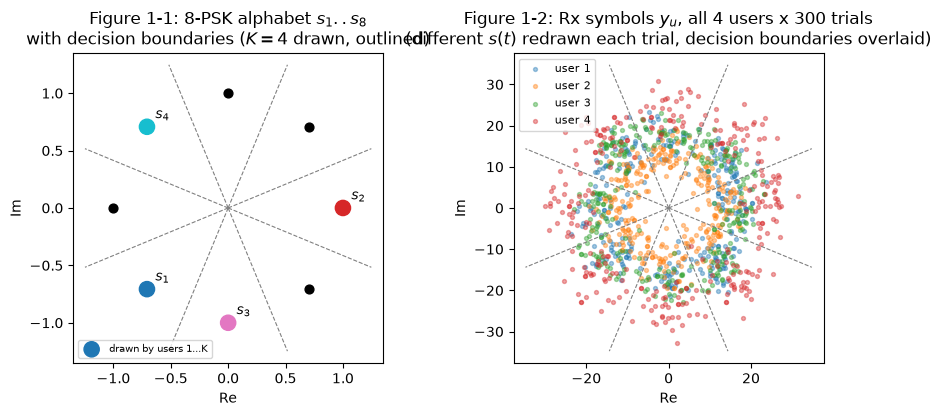

noise std used: sigma_C=0.3162 (SNR_C=10dB); per-user Rx-symbol scatter std over 300 trials, e.g. user 1 (Re, Im) ~= (12.3436, 12.0863)


In [10]:
M, K, Nt = 8, 4, 32 
sigma_C = 10 ** (-10.0 / 20)    # SNR_C = 10 dB 

def draw_psk_symbols(K, M, rng): 
    k = rng.integers(0, M, size=K) 
    return np.exp(1j * 2.0 * np.pi * k / M) 

def draw_block_rayleigh_channels(Nt, K, rng): 
    re = rng.standard_normal((Nt, K)) 
    im = rng.standard_normal((Nt, K)) 
    return (re + 1j * im) / np.sqrt(2.0) 

s = draw_psk_symbols(K, M, RNG) 
H = draw_block_rayleigh_channels(Nt, K, RNG) 


# sign-MRT seed: The comm-optimal direction
def sign_project(v): 
    return np.where(v >= 0.0, 1.0, -1.0) 

def complex_to_composite(x_c): 
    return np.concatenate([x_c.real, x_c.imag]) 

def composite_to_complex(x_tilde): 
    Nt = len(x_tilde) // 2 
    return x_tilde[:Nt] + 1j * x_tilde[Nt:2 * Nt]


mrt_direction = np.sum(H * np.exp(1j * np.angle(s)), axis=1) 
x_tilde = sign_project(complex_to_composite(mrt_direction)) 
x_c = composite_to_complex(x_tilde) 


fig, axes = plt.subplots(1, 2, figsize=(9, 4.2)) 
theta = np.linspace(0, 2 * np.pi, 200) 

# The M ideal alphabet points s_1 ... s_M 
ideal_syms = np.exp(1j * 2.0 * np.pi * np.arange(M) / M) 
boundary_angles = (2.0 * np.arange(M) + 1.0 ) * np.pi / M 
edge0 = 1.35
for ang in boundary_angles: 
    axes[0].plot([0, edge0 * np.cos(ang)], [0, edge0 * np.sin(ang)], color='gray', lw=0.8, ls='--') 
axes[0].scatter(ideal_syms.real, ideal_syms.imag, color='black', s=40, zorder=3) 
axes[0].scatter(s.real, s.imag, c=range(K), cmap='tab10', s=120, zorder=4, label="drawn by users 1...K")  
for i, su in enumerate(s): 
    axes[0].annotate(f"$s_{i + 1}$", (su.real, su.imag), textcoords="offset points", xytext=(6, 6)) 

axes[0].set_xlim(-edge0, edge0); axes[0].set_ylim(-edge0, edge0)
axes[0].set_aspect("equal")
axes[0].set_title(f"Figure 1-1: {M}-PSK alphabet $s_1..s_{{{M}}}$\nwith decision boundaries ($K={K}$ drawn, outlined)")
axes[0].set_xlabel("Re"); axes[0].set_ylabel("Im"); axes[0].legend(fontsize=7, loc="lower left")

n_trials = 300 
Y = np.empty((n_trials, K), dtype=complex) 
for i in range(n_trials): 
    s_i = draw_psk_symbols(K, M, RNG) 
    mrt_i = np.sum(H * np.exp(1j * np.angle(s_i)), axis=1) 
    x_tilde_i = sign_project(complex_to_composite(mrt_i)) 
    x_c_i = composite_to_complex(x_tilde_i) 
    noise_i = (RNG.standard_normal(K) + 1j * RNG.standard_normal(K)) * sigma_C / np.sqrt(2.0) 
    Y[i] = H.conj().T @ x_c_i #+ noise_i 

edge1 = 1.15 * np.max(np.abs(np.stack([Y.real, Y.imag])))
for ang in boundary_angles:
    axes[1].plot([0, edge1 * np.cos(ang)], [0, edge1 * np.sin(ang)], color='gray', lw=0.8, ls='--') 

cmap = plt.get_cmap('tab10') 

for u in range(K):
    axes[1].scatter(Y[:, u].real, Y[:, u].imag, s=8, alpha=0.4, color=cmap(u), label=f"user {u+1}")
axes[1].set_xlim(-edge1, edge1); axes[1].set_ylim(-edge1, edge1)
axes[1].set_aspect("equal"); axes[1].legend(fontsize=8)
axes[1].set_title(f"Figure 1-2: Rx symbols $y_u$, all {K} users x {n_trials} trials\n(different $s(t)$ redrawn each trial, decision boundaries overlaid)")
axes[1].set_xlabel("Re"); axes[1].set_ylabel("Im")
plt.tight_layout(); plt.show()

print(f"noise std used: sigma_C={sigma_C:.4f} (SNR_C=10dB); "
      f"per-user Rx-symbol scatter std over {n_trials} trials, e.g. user 1 (Re, Im) "
      f"~= ({Y[:, 0].real.std():.4f}, {Y[:, 0].imag.std():.4f})")

## 1-2. Symbol-frame rotation and the safe-margin wedge 

Rotating the channel by the desired symbol's phase maps every $M$-PSK symbol's correct 
decision region onto the same wedge around the positive real axis. So, one pair of linear
inequalities per user suffices regardless of which of the $M$ symbols was sent: 
$$ \begin{equation} 
    \bar{h}_{u}(t) = h_{u}(t) \exp(-j \angle s_u(t)), \quad 
    \bar{y}_{u}(t) = \bar{h}_{u}(t)^{\mathrm{H}} x(t). 
\end{equation} $$
Correct detection with safe margin $\mu$ is for wedge half-angle $\pi/M$: 
$$ 
\begin{equation} 
    \tan\left(\frac{\pi}{M}\right) \Re \{\bar{y}_{u}\} - \Im \{\bar{y}_{u}\} \ge \mu, \quad \tan \left(\frac{\pi}{M}\right) \Re \{\bar{y}_{u}\} + \Im \{\bar{y}_{u}\} \ge \mu.
\end{equation}
$$
Stacking both rows for all $K$ users gives the real-embedded safe-margin matrix $A_{C} \in \mathbb{R}^{2K \times 2N_T}$ so that $A_{C}\tilde{x} \ge \mu \mathbf{1}_{2K}$ holds iff every user's noiseless received point sits at least $\mu$ inside its wedge – the worst-case margin is $\mu(t) = \min_{u} (A_C \tilde{x})_u$.


A_C shape:  (8, 64) (2K x 2Nt) | realized max-min margin mu= 3.581


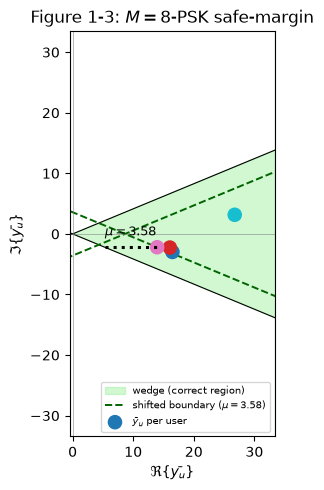

In [27]:
def rotate_to_symbol_frame(H, s): 
    return H * np.exp(1j * np.angle(s)) 

def margin_constraints_psk(bar_h, M): 
    Nt, K = bar_h.shape 
    t = np.tan(np.pi / M) 
    rows = np.empty((2 * K, 2 * Nt)) 
    for uu in range(K): 
        h_re, h_im = bar_h[:, uu].real, bar_h[:, uu].imag 
        rows[2 * uu] = np.concatenate([t * h_re + h_im, t * h_im - h_re]) 
        rows[2 * uu + 1] = np.concatenate([t * h_re - h_im, t * h_im + h_re]) 

    return rows 

bar_h = rotate_to_symbol_frame(H, s) 
A_C = margin_constraints_psk(bar_h, M) 
bar_y = bar_h.conj().T @ x_c 
mu_realized = float(np.min(A_C @ x_tilde)) 
print("A_C shape: ", A_C.shape, "(2K x 2Nt) | realized max-min margin mu=", round(mu_realized, 3)) 

t = np.tan(np.pi / M) 
cmap = plt.get_cmap("tab10") 

edge = max(2.5, 1.25 * np.max(np.abs(np.concatenate([bar_y.real, bar_y.imag, [mu_realized]]))))
xx = np.linspace(-edge, edge, 300) 


fig, ax = plt.subplots(figsize=(5, 5)) 
ax.fill_betweenx(xx, np.abs(xx)/ t, edge, color='lightgreen', alpha=0.4, label='wedge (correct region)') 
ax.plot(xx/ t, xx, 'k-', lw=0.8); ax.plot(xx / t, -xx, 'k-', lw=0.8) 
# shifted boundary 
ax.plot(xx / t + mu_realized / t, xx, color='darkgreen', lw=1.4, ls='--', label=fr"shifted boundary ($\mu={mu_realized:.2f}$)") 
ax.plot(-xx / t + mu_realized / t, xx, color='darkgreen', lw=1.4, ls='--')

gaps = bar_y.real - np.abs(bar_y.imag) / t 
uu_min = int(np.argmin(gaps)) 
x0, y0 = bar_y[uu_min].real, bar_y[uu_min].imag 
x_boundary = np.abs(y0) / t 
ax.plot([x_boundary, x0], [y0, y0], color='black', lw=2.2, ls=":", zorder=4) 
ax.annotate(fr"$\mu={mu_realized:.2f}$", ((x_boundary + x0 ) / 2, y0),
            textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9, 
            color="black", fontweight="bold")
ax.scatter(bar_y.real, bar_y.imag, c=range(K), cmap='tab10', s=90, zorder=3, label=r"$\bar y_u$ per user")
ax.axhline(0, color='gray', lw=0.4); ax.axvline(0, color='gray', lw=0.4)
ax.set_xlim(-0.5, edge); ax.set_ylim(-edge, edge); ax.set_aspect("equal")
ax.set_xlabel(r"$\Re\{\bar{y_u}\}$"); ax.set_ylabel(r"$\Im \{ \bar{y_u} \}$")
ax.set_title(f"Figure 1-3: $M={M}$-PSK safe-margin") 
ax.legend(fontsize=7, loc='lower right') 
plt.tight_layout(); plt.show()


A_C shape: (8, 64) (2K x 2Nt) | realized max-min margin mu = 3.581


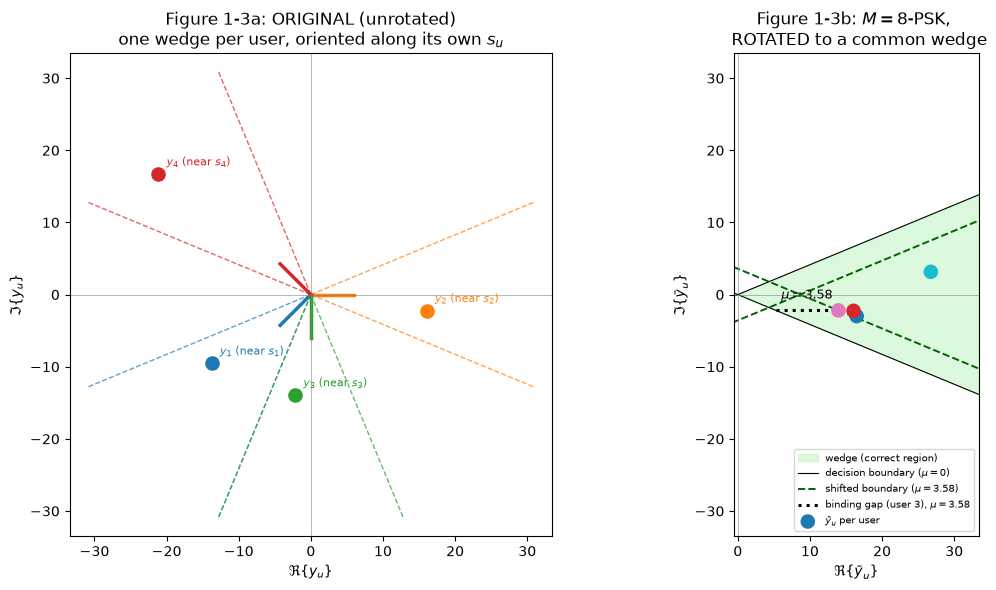

In [32]:

def rotate_to_symbol_frame(H, s):
    return H * np.exp(1j * np.angle(s))

def margin_constraints_psk(bar_h, M):
    Nt, K = bar_h.shape
    t = np.tan(np.pi / M)
    rows = np.empty((2 * K, 2 * Nt))
    for uu in range(K):
        h_re, h_im = bar_h[:, uu].real, bar_h[:, uu].imag
        rows[2 * uu] = np.concatenate([t * h_re + h_im, t * h_im - h_re])
        rows[2 * uu + 1] = np.concatenate([t * h_re - h_im, t * h_im + h_re])
    return rows

bar_h = rotate_to_symbol_frame(H, s)
A_C = margin_constraints_psk(bar_h, M)
bar_y = bar_h.conj().T @ x_c  # (K,) rotated noiseless received points
y_noiseless = H.conj().T @ x_c  # (K,) ORIGINAL (unrotated) noiseless received points, Eq. 3
mu_realized = float(np.min(A_C @ x_tilde))
print("A_C shape:", A_C.shape, "(2K x 2Nt) | realized max-min margin mu =", round(mu_realized, 3))

t = np.tan(np.pi / M)
cmap = plt.get_cmap("tab10")

# The rotated points bar_y scale with sqrt(Nt) (Nt=32 unit +-1 taps summed),
# so a fixed +-2.5 window used to clip them -- size the plot to the actual
# data instead, with headroom for the shifted boundary drawn below. Rotation
# preserves modulus, so the same edge fits both subfigures.
edge = max(2.5, 1.25 * np.max(np.abs(np.concatenate([bar_y.real, bar_y.imag, [mu_realized]]))))
xx = np.linspace(-edge, edge, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Left: the ORIGINAL (non-rotated) picture, on a constellation ---
# y_u = h_u^H x lives in a wedge centered on the user's OWN symbol direction
# angle(s_u), half-angle pi/M -- one differently-oriented wedge per user,
# since nothing has been rotated into a common frame yet.
for uu in range(K):
    phi_u = np.angle(s[uu])
    color = cmap(uu)
    for ang in (phi_u - np.pi / M, phi_u + np.pi / M):
        axes[0].plot([0, edge * np.cos(ang)], [0, edge * np.sin(ang)], color=color, lw=1.0, ls="--", alpha=0.7)
    axes[0].plot([0, 0.18 * edge * np.cos(phi_u)], [0, 0.18 * edge * np.sin(phi_u)], color=color, lw=2.5)
    y0 = y_noiseless[uu]
    axes[0].scatter([y0.real], [y0.imag], color=color, s=90, zorder=5)
    axes[0].annotate(f"$y_{uu+1}$ (near $s_{uu+1}$)", (y0.real, y0.imag),
                      textcoords="offset points", xytext=(6, 6), fontsize=8, color=color)
axes[0].axhline(0, color="gray", lw=0.4); axes[0].axvline(0, color="gray", lw=0.4)
axes[0].set_xlim(-edge, edge); axes[0].set_ylim(-edge, edge); axes[0].set_aspect("equal")
axes[0].set_xlabel(r"$\Re\{y_u\}$"); axes[0].set_ylabel(r"$\Im\{y_u\}$")
axes[0].set_title("Figure 1-3a: ORIGINAL (unrotated)\none wedge per user, oriented along its own $s_u$")

# --- Right: after symbol-frame rotation, every user's wedge is the SAME
# wedge around the positive real axis (Eq. 4-5) -- this is what makes a
# single pair of linear constraints per user possible in A_C.
ax = axes[1]
ax.fill_betweenx(xx, np.abs(xx) / t, edge, color="lightgreen", alpha=0.3, label="wedge (correct region)")
ax.plot(xx / t, xx, "k-", lw=0.8, label="decision boundary ($\\mu=0$)")
ax.plot(xx / t, -xx, "k-", lw=0.8)
# Shifted boundary: the wedge offset inward by the realized margin mu, i.e.
# the two lines t*Re-Im=mu and t*Re+Im=mu -- the region every user's bar_y
# must clear for the *worst-case* user to have safe margin mu.
ax.plot(xx / t + mu_realized / t, xx, color="darkgreen", lw=1.4, ls="--",
        label=fr"shifted boundary ($\mu={mu_realized:.2f}$)")
ax.plot(-xx / t + mu_realized / t, xx, color="darkgreen", lw=1.4, ls="--")

# for uu in range(len(bar_y)):
#     x0, y0 = bar_y[uu].real, bar_y[uu].imag
#     # Radial guide from the origin so every point -- even ones near the plot
#     # edge -- is unambiguously connected back to where it came from.
#     ax.plot([0, x0], [0, y0], color=cmap(uu), lw=0.7, alpha=0.5, zorder=2)

# Only the *worst-case* user sets mu_realized = min_u min(m1_u, m2_u); the
# horizontal gap x0-|y0|/t to the nearer boundary equals that user's margin
# divided by t, so its argmin also locates the binding user -- annotate only
# that one gap instead of all K.
gaps = bar_y.real - np.abs(bar_y.imag) / t
uu_min = int(np.argmin(gaps))
x0, y0 = bar_y[uu_min].real, bar_y[uu_min].imag
x_boundary = np.abs(y0) / t
ax.plot([x_boundary, x0], [y0, y0], color="black", lw=2.2, ls=":", zorder=4,
        label=fr"binding gap (user {uu_min+1}), $\mu={mu_realized:.2f}$")
ax.annotate(fr"$\mu={mu_realized:.2f}$", ((x_boundary + x0) / 2, y0),
            textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9,
            color="black", fontweight="bold")

ax.scatter(bar_y.real, bar_y.imag, c=range(len(bar_y)), cmap="tab10", s=90, zorder=5, label=r"$\bar y_u$ per user")
ax.axhline(0, color="gray", lw=0.4); ax.axvline(0, color="gray", lw=0.4)
ax.set_xlim(-0.5, edge); ax.set_ylim(-edge, edge); ax.set_aspect("equal")
ax.set_xlabel(r"$\Re\{\bar y_u\}$"); ax.set_ylabel(r"$\Im\{\bar y_u\}$")
ax.set_title(f"Figure 1-3b: $M={M}$-PSK, \n ROTATED to a common wedge")
ax.legend(fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()


## 1-3. Max-min safe margin as a linear program 

The worst case safe margin is the epigraph variable: 
$$ 
\begin{equation} 
    \mu(t) = \max \{ \mu : A_C \tilde{x} \ge \mu \mathbf{1}_{2K}\}, \quad \tilde{x} \in [-1, 1]^{2N_T}. \: \text{(LP relaxation)} 
\end{equation}
$$
This is a linear program (LP) in the real domain: $(\tilde{x}, \mu) \in \mathbb{R}^{2N_T + 1}$, maximizing $\mu$ subject to $A_C \tilde{x} - \mu \mathbf{1}_{2K} \ge 0$, and box bounds $-1 \le \tilde{x}_i \le 1$.

LP feasible:  True mu_lp= 7.0887
fraction of coordinates left non-integral: 0.109375


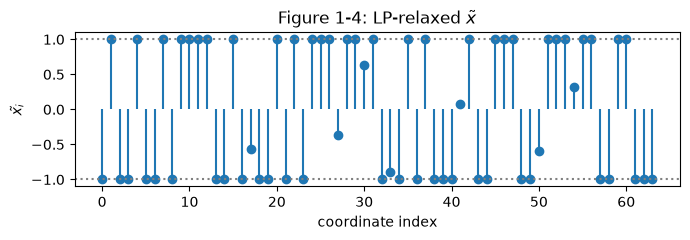

In [33]:
def solve_comm_LP(A): 
    n_rows, n = A.shape 
    # variables:" [x (n,), mu (1,)]; maximize mu <=> minimize -mu"
    c = np.concatenate([np.zeros(n), [-1.0]]) 
    A_ub = np.hstack([-A, np.ones((n_rows, 1))])    # -Ax + mu <= 0 
    b_ub = np.zeros(n_rows) 
    bounds = [(-1.0, 1.0)] * n + [(0.0, None)] 
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs") 
    return res.x[:n], float(res.x[n]), res.success 

x_frac, mu_lp, ok = solve_comm_LP(A_C) 
print("LP feasible: ", ok, 'mu_lp=', round(mu_lp, 4)) 
print("fraction of coordinates left non-integral:", np.mean(np.abs(x_frac) < 1- 1e-6)) 

fig, ax = plt.subplots(figsize=(7, 2.5)) 
ax.stem(x_frac, basefmt=" ") 
ax.axhline(1, color='gray', ls=':'); ax.axhline(-1, color='gray', ls=":") 
ax.set_title("Figure 1-4: LP-relaxed $\\tilde x$") 
ax.set_xlabel("coordinate index"); ax.set_ylabel(r"$\tilde{x_i}$") 
plt.tight_layout(); plt.show() 

## 1-4. Greedy rounding to $\{-1, 1\}$ 

The LP relaxation above is already almost integral: only a handful of coordinates land strictly inside the box $(-1, 1)$. __P-Greedy__ rounds by seeding $x=\mathrm{sign}(x_{\rm frac})$ and sweeping only those fractional coordinates, flipping each to whichever of $\{-1, 1\}$ improves the objective – here, plain margin maximization (the fused DPP score in EQ. 15's rounding step reduces to this when Z = 0). 


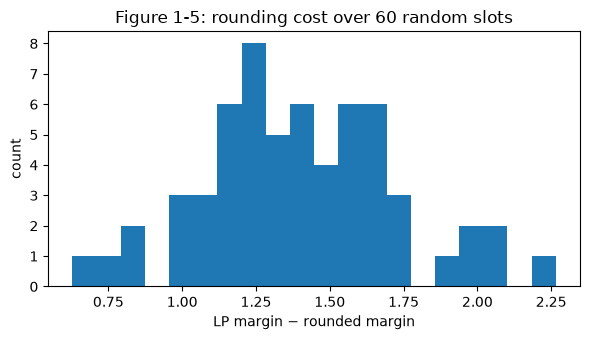

In [34]:
def greedy_round_comm(x_frac, A, eps=1e-6): 
    x = sign_project(x_frac) 
    frac_idx = np.where(np.abs(x_frac) < 1-eps)[0] 
    def margin(c): 
        return float(np.min(A @ c)) 
    for i in frac_idx: 
        best, best_score = x, margin(x) 
        for v in (-1.0, 1.0): 
            cand = x.copy(); cand[i] = v 
            sc = margin(cand) 
            if sc > best_score: 
                best, best_score = cand, sc 
        x = best 
    return x 

n_trials = 60 
gaps = [] 
for _ in range(n_trials): 
    Ht = draw_block_rayleigh_channels(Nt, K, RNG) 
    st = draw_psk_symbols(K, M, RNG) 
    At = margin_constraints_psk(rotate_to_symbol_frame(Ht, st), M) 
    xf, mu_before, _ = solve_comm_LP(At) 
    xr = greedy_round_comm(xf, At) 
    mu_after = float(np.min(At @ xr)) 
    gaps.append(mu_before - mu_after) 

fig, ax = plt.subplots(figsize=(6, 3.5)) 
ax.hist(gaps, bins=20) 
ax.set_xlabel(r"LP margin $-$ rounded margin"); ax.set_ylabel("count") 
ax.set_title(f"Figure 1-5: rounding cost over {n_trials} random slots")
plt.tight_layout(); plt.show() 


## 1-5. Symbol error probability (SEP) and bit error rate (BER) from the margin 

Wang et al's bound (adapted to this margin convention) gives the SEP from the time-averaged margin: 
$$\begin{equation} 
    \mathrm{SEP}_{\mathrm{lb}} = \psi \left( 
        \frac{\sqrt{2} \cos (\pi / M) \mu}{\sigma_C}        
    \right), \quad \psi(z) = \frac{1}{2} \mathrm{erfc}(z / \sqrt(2)),
\end{equation}$$
with an upper bound $\min(2 \mathrm{SEP_{lb}}, 1)$. Larget margin => lower SEP

trials per MC point (min..max): 200000 .. 16663570


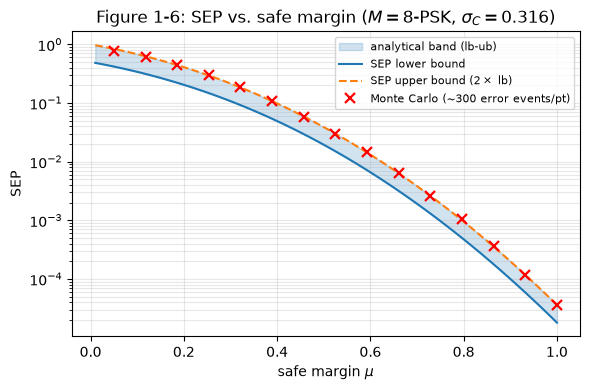

In [39]:
def psi(z): 
    return 0.5 * erfc(z / np.sqrt(2.0)) 

t = np.tan(np.pi / M) 

mu_grid = np.linspace(0.01, 1.0, 100)
z = np.sqrt(2.0) * np.cos(np.pi / M) * mu_grid / sigma_C
sep_lb = psi(z)
sep_ub = np.minimum(2 * sep_lb, 1.0)

mu_mc = np.linspace(0.05, 1.0, 15) 
target_errors = 300 
n_min, n_max = 200_000, 20_000_000 
sep_lb_mc = psi(np.sqrt(2.0) * np.cos(np.pi /M) * mu_mc / sigma_C) 
n_mc_per_pt = np.clip((target_errors / sep_lb_mc).astype(int), n_min, n_max)

sep_mc = np.empty_like(mu_mc) 
for i, (mu, n_mc) in enumerate(zip(mu_mc, n_mc_per_pt)): 
    bar_y0 = mu / t + 0j 
    noise = (RNG.standard_normal(n_mc) + 1j * RNG.standard_normal(n_mc)) * sigma_C / np.sqrt(2.0) 
    y_noisy = bar_y0 + noise 
    correct = (t * y_noisy.real - y_noisy.imag >= 0) & (t * y_noisy.real + y_noisy.imag >= 0) 
    sep_mc[i] = np.mean(~correct) 
sep_mc_plot = np.where(sep_mc > 0, sep_mc, np.nan) 
print("trials per MC point (min..max):", n_mc_per_pt.min(), "..", n_mc_per_pt.max()) 

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(mu_grid, sep_lb, sep_ub, color="tab:blue", alpha=0.2, label="analytical band (lb-ub)")
ax.semilogy(mu_grid, sep_lb, label="SEP lower bound")
ax.semilogy(mu_grid, sep_ub, "--", label="SEP upper bound ($2\\times$ lb)")
ax.semilogy(mu_mc, sep_mc_plot, "x", color="red", ms=7, mew=1.6, zorder=5,
            label=f"Monte Carlo (~{target_errors} error events/pt)")
ax.set_xlabel(r"safe margin $\mu$"); ax.set_ylabel("SEP")
ax.set_title(f"Figure 1-6: SEP vs. safe margin ($M={M}$-PSK, $\\sigma_C={sigma_C:.3f}$)")
ax.legend(fontsize=8); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()